1000


/Users/A200035342/anaconda3/lib/python3.11/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoost Classifier Performance:
Accuracy: 0.85
              precision    recall  f1-score   support

           0       0.88      0.83      0.86       160
           1       0.82      0.87      0.84       140

    accuracy                           0.85       300
   macro avg       0.85      0.85      0.85       300
weighted avg       0.85      0.85      0.85       300


Gradient Boosting Classifier Performance:
Accuracy: 0.89
              precision    recall  f1-score   support

           0       0.91      0.87      0.89       160
           1       0.86      0.91      0.88       140

    accuracy                           0.89       300
   macro avg       0.89      0.89      0.89       300
weighted avg       0.89      0.89      0.89       300



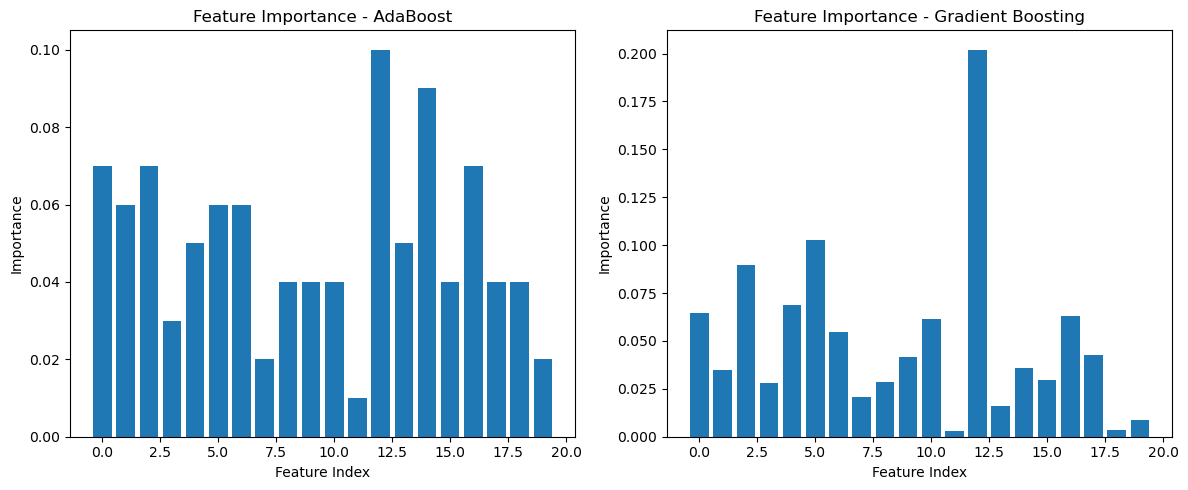

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Step 1: Generate synthetic data using make_classification
X, y = make_classification(
    n_samples=1000,       # Number of samples
    n_features=20,        # Number of features
    n_informative=15,     # Number of informative features
    n_redundant=5,        # Number of redundant features
    random_state=42       # Set random seed for reproducibility
)

print(len(X))
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


# Step 2: Train AdaBoostClassifier
ada_model = AdaBoostClassifier(n_estimators=100, random_state=42)
ada_model.fit(X_train, y_train)

# Step 3: Train GradientBoostingClassifier
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_model.fit(X_train, y_train)

# Step 4: Make predictions
y_pred_ada = ada_model.predict(X_test)
y_pred_gb = gb_model.predict(X_test)

# Step 5: Evaluate the models
print("AdaBoost Classifier Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_ada):.2f}")
print(classification_report(y_test, y_pred_ada))

print("\nGradient Boosting Classifier Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_gb):.2f}")
print(classification_report(y_test, y_pred_gb))

# Step 6: Plot feature importance for both models
# Note: AdaBoost and Gradient Boosting can provide feature importances
importances_ada = ada_model.feature_importances_
importances_gb = gb_model.feature_importances_

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(range(X.shape[1]), importances_ada)
plt.title("Feature Importance - AdaBoost")
plt.xlabel("Feature Index")
plt.ylabel("Importance")

plt.subplot(1, 2, 2)
plt.bar(range(X.shape[1]), importances_gb)
plt.title("Feature Importance - Gradient Boosting")
plt.xlabel("Feature Index")
plt.ylabel("Importance")

plt.tight_layout()
plt.show()
